## Problem 2: Calculate and visualise the *dominance areas* of shopping centres (10 points)

In this problem, the aim is to delineate the dominance area of each shopping centre. For this 
exercise, we define the ‘dominance area’ of a shopping centre as the area from which it can 
be reached faster than other shopping centres. We will use public transport travel times.

![](images/dominance_areas_example_1000x500px.png)

*Sample result: a map showing the areas of dominance of each shopping centre, and the travel 
times to the closest shopping centre in the entire metropolitan area*



---

### Data

The **input data** is identical to what you have used for *problem 1*, 
see [there](./Exercise-4-problem-1.ipynb) for detailed data descriptions.

---


### An overview of the tasks

This task comprises of three major subtasks. In contrast to earlier exercises, we 
do not provide a detailed, step-by-step ‘cooking recipe’. Rather, you are free to
implement the necessary steps in any order you see fit, and choose any variable
names of your liking. 

To test intermediate results, implement `assert` statements, output the `head()`
of a data frame, or plot the data. Remember to add comments to all of your code,
so future you (and us) can understand what each section does.

The **only strict requirement** is the **file name** of
the **output** map plot: `DATA_DIRECTORY / "dominance_areas.png"`.

1. Load the YKR grid and the individual travel time data sets, and combine them 
   into one geo data frame. This is essentially the same as *problem 1*, except
   that you must load all eight shopping centre data files. (2 points)
2. Find the closest shopping centre to each grid cell. In the combined data set,
   find the minimum travel time to any of the shopping centres, save the value in
   a new column, and shopping centre name in another new column. (4 points)
   See the [hints](https://autogis-site.readthedocs.io/en/latest/lessons/lesson-4/exercise-4.html#hints)
   to this exercise for a suggestions on how to achieve this 
   ([`pandas.DataFrame.min()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.min.html) and
   [`pandas.DataFrame.idxmin()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.idxmin.html)
   will be helpful)
3. Visualise the dominance areas and travel times. Use 2⨉1 subplots to plot
   the most dominant (closest) shopping centre for each grid cell, and the
   travel time to the closest shopping centre for each grid cell. (4 points)

---


In [3]:
import pathlib 
NOTEBOOK_PATH = pathlib.Path().resolve()
DATA_DIRECTORY = NOTEBOOK_PATH / "data"

In [4]:
# Import grid
import geopandas as gpd

# Read file
grid = gpd.read_file(DATA_DIRECTORY / "YKR_grid_EPSG3067.gpkg")

grid.head()

,YKR_ID,geometry
0,5785640,"POLYGON ((382000.000 6697750.000, 381750.000 6..."
1,5785641,"POLYGON ((382250.000 6697750.000, 382000.000 6..."
2,5785642,"POLYGON ((382500.000 6697750.000, 382250.000 6..."
3,5785643,"POLYGON ((382750.000 6697750.000, 382500.000 6..."
4,5787544,"POLYGON ((381250.000 6697500.000, 381000.000 6..."


In [5]:
# 1. Import travel time data sets
import numpy
import pandas as pd

# Discard irrelevant columns
cols = ['from_id', 'to_id', 'pt_r_t']

# Read data sets for the shopping centres 'Itis' and 'Myyrmanni'
for file in DATA_DIRECTORY.glob("travel_times_to_*.txt"):
    # Extract shopping centre name from file
    name = file.stem.split("_")[-1] # Jumbo, Dixi...
    
    # Read travel times
    travel_times = pd.read_csv(file, sep=";", usecols=cols)
    
    #Rename columns
    travel_times = travel_times.rename(columns={
        "pt_r_t": f"pt_r_t_{name}"})
    
    # Replace no-data values (-1) with NaN
    travel_times = travel_times.replace({-1: numpy.nan})
    
    # Join the renamed columns to the grid
    grid = grid.merge(travel_times, left_on="YKR_ID", right_on="from_id", how="left")

/srv/conda/envs/notebook/lib/python3.10/site-packages/geopandas/geodataframe.py:1470: FutureWarning: Passing 'suffixes' which cause duplicate columns {'to_id_x', 'from_id_x'} in the result is deprecated and will raise a MergeError in a future version.
  result = DataFrame.merge(self, *args, **kwargs)
/srv/conda/envs/notebook/lib/python3.10/site-packages/geopandas/geodataframe.py:1470: FutureWarning: Passing 'suffixes' which cause duplicate columns {'to_id_x', 'from_id_x'} in the result is deprecated and will raise a MergeError in a future version.
  result = DataFrame.merge(self, *args, **kwargs)


In [6]:
# NON-EDITABLE TEST CELL
import geopandas
assert type(grid) == geopandas.geodataframe.GeoDataFrame, "Output should be a geodataframe."

In [7]:
grid.head()

,YKR_ID,geometry,from_id_x,to_id_x,pt_r_t_Ruoholahti,from_id_y,to_id_y,pt_r_t_Omena,from_id_x,to_id_x,...,pt_r_t_Forum,from_id_x,to_id_x,pt_r_t_Myyrmanni,from_id_y,to_id_y,pt_r_t_Jumbo,from_id,to_id,pt_r_t_Dixi
0,5785640,"POLYGON ((382000.000 6697750.000, 381750.000 6...",5785640,5980260.0,118.0,5785640,5978593.0,141.0,5785640,5944003.0,...,110.0,5785640,5902043.0,90.0,5785640,5878070.0,101.0,5785640,5878087.0,102.0
1,5785641,"POLYGON ((382250.000 6697750.000, 382000.000 6...",5785641,5980260.0,121.0,5785641,5978593.0,143.0,5785641,5944003.0,...,113.0,5785641,5902043.0,93.0,5785641,5878070.0,108.0,5785641,5878087.0,109.0
2,5785642,"POLYGON ((382500.000 6697750.000, 382250.000 6...",5785642,5980260.0,123.0,5785642,5978593.0,145.0,5785642,5944003.0,...,115.0,5785642,5902043.0,95.0,5785642,5878070.0,109.0,5785642,5878087.0,111.0
3,5785643,"POLYGON ((382750.000 6697750.000, 382500.000 6...",5785643,5980260.0,127.0,5785643,5978593.0,149.0,5785643,5944003.0,...,119.0,5785643,5902043.0,99.0,5785643,5878070.0,114.0,5785643,5878087.0,115.0
4,5787544,"POLYGON ((381250.000 6697500.000, 381000.000 6...",5787544,5980260.0,111.0,5787544,5978593.0,134.0,5787544,5944003.0,...,103.0,5787544,5902043.0,83.0,5787544,5878070.0,98.0,5787544,5878087.0,99.0


In [9]:
# 2. Find the closest shopping centre to each grid cell

# List of columns with travel times (all start with pt_r_t_)
travel_time_columns = [col for col in grid.columns if col.startswith('pt_r_t_')]

# For each grid cell: Find the minimum travel time to any shopping centre
grid['min_travel_time'] = grid[travel_time_columns].min(axis=1)

# For each grid cell: Find which shopping centre has that minimum time (returns the column name)
grid['closest_centre_col'] = grid[travel_time_columns].idxmin(axis=1)

# Extract only the centre name (remove the 'pt_r_t_' prefix)
grid['closest_centre'] = grid['closest_centre_col'].str.replace('pt_r_t_', '')

# Opcional: eliminar la columna auxiliar
grid = grid.drop(columns=['closest_centre_col'])

# Verificar resultado
print(grid[['YKR_ID', 'min_travel_time', 'closest_centre']].head(10))

    YKR_ID  min_travel_time closest_centre
0  5785640             90.0      Myyrmanni
1  5785641             93.0      Myyrmanni
2  5785642             95.0      Myyrmanni
3  5785643             99.0      Myyrmanni
4  5787544             83.0      Myyrmanni
5  5787545             84.0      Myyrmanni
6  5787546             88.0      Myyrmanni
7  5787547            100.0      Myyrmanni
8  5787548             97.0      Myyrmanni
9  5787549            101.0      Myyrmanni


/tmp/ipykernel_550/1572254951.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.91, 0.96])


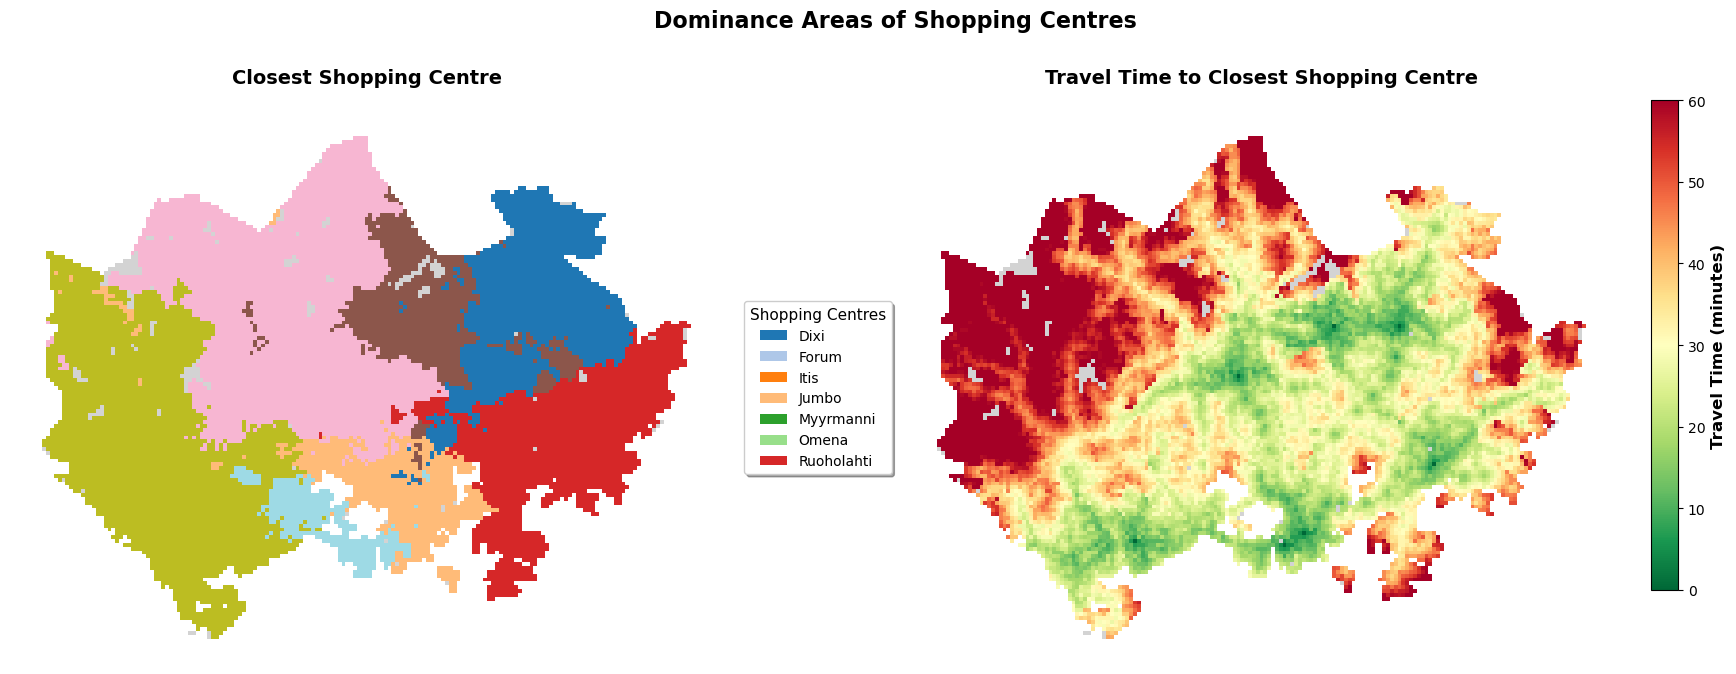

In [10]:
# 3. Visualize the dominance areas and traves times
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# Prepare data for the closest shopping centre map
# Get unique list of shopping centres
centres = grid['closest_centre'].unique()
centres = sorted([c for c in centres if pd.notna(c)])

# Create numerical mapping for centres
centre_to_num = {centre: idx for idx, centre in enumerate(centres)}
grid['closest_centre_num'] = grid['closest_centre'].map(centre_to_num)

# Create figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# MAP 1: Closest shopping centres (left)
ax1 = axes[0]
grid.plot(
    column='closest_centre_num',
    ax=ax1,
    cmap='tab20',  # Categorical colormap
    legend=False,
    missing_kwds={"color": "lightgrey"},
    linewidth=0,
)
ax1.set_title("Closest Shopping Centre", fontsize=14, fontweight="bold", pad=20)
ax1.set_axis_off()

# Create custom legend for centres (left)
colours = plt.cm.tab20(range(len(centres)))
legend_elements = [Patch(facecolor=colours[centre_to_num[centre]], 
                         label=centre) 
                   for centre in centres]
ax1.legend(handles=legend_elements, 
          loc='center left', 
          bbox_to_anchor=(1.02, 0.5),
          fontsize=10,
          title='Shopping Centres',
          title_fontsize=11,
          frameon=True,
          fancybox=True,
          shadow=True)

# MAP 2: Travel time (right)
ax2 = axes[1]

# Normalize travel times in 10-minute intervals
norm = mcolors.Normalize(vmin=0, vmax=60)
cmap = plt.cm.RdYlGn_r

grid.plot(
    column='min_travel_time',
    ax=ax2,
    cmap=cmap,
    norm=norm,
    legend=False,
    missing_kwds={"color": "lightgrey"},
    linewidth=0,
)
ax2.set_title("Travel Time to Closest Shopping Centre", fontsize=14, fontweight="bold", pad=20)
ax2.set_axis_off()

# Color bar for travel times
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, cax=cbar_ax, 
                    ticks=[0, 10, 20, 30, 40, 50, 60])
cbar.ax.set_yticklabels(["0", "10", "20", "30", "40", "50", "60"])
cbar.set_label("Travel Time (minutes)", fontsize=12, fontweight="bold")

# Overall title
fig.suptitle(
    "Dominance Areas of Shopping Centres",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

fig.tight_layout(rect=[0, 0, 0.91, 0.96])
fig.savefig(DATA_DIRECTORY / "dominance_areas.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# NON-EDITABLE TEST CELL
# Check that output figure file exists
assert (DATA_DIRECTORY / "dominance_areas.png").exists()


--- 

**Do not forget to plot the result map, and save it to `DATA_DIRECTORY / "dominance_areas.png"`!**

---

## Reflections

This was a significantly more complex exercise that previous ones, and it included finding
a solution yourself. 

- What was most difficult part? 
- Where did you get stuck? 
- What was the easiest, and
- what was the most fun part of this exercise?

Add your answer below


---

## Well done!

Congratulations, you completed exercise 4. Good Job!